# Case study
Analysis of dataset, which consists of data about medical insurance <br> https://www.kaggle.com/datasets/mirichoi0218/insurance

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv('data/04-insurance.csv')

# Preview
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Initial Data Inspection
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data cleaning

In [4]:
# Handle Missing Values (if any)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [5]:
# Check Duplicates
df.duplicated().sum()
df = df.drop_duplicates()

## Feature Engineering

In [6]:
# Log Transformation (handle skewness)
df['log_charges'] = np.log(df['charges'] + 1)

In [7]:
# BMI Categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'


df['bmi_category'] = df['bmi'].apply(bmi_category)

## Exploratory Data Analysis (EDA)

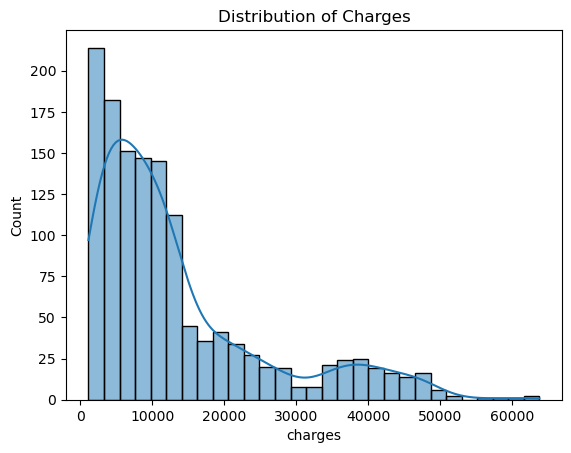

In [8]:
# Univariate Analysis
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges')
plt.show()

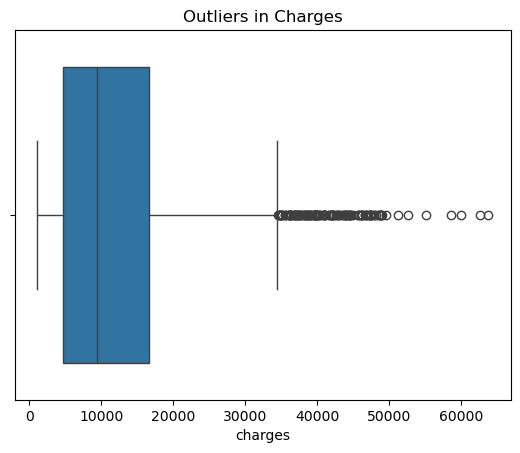

In [9]:
sns.boxplot(x=df['charges'])
plt.title('Outliers in Charges')
plt.show()

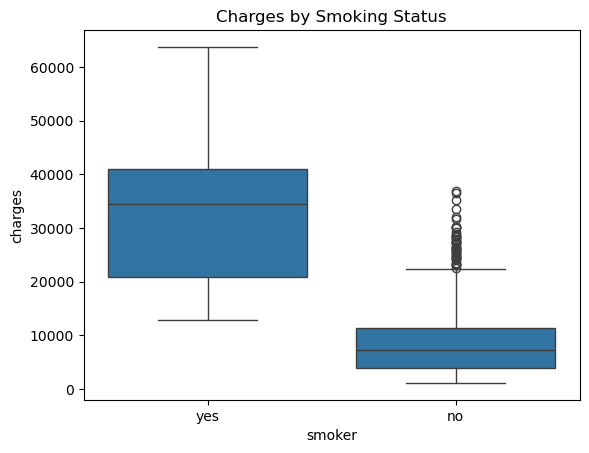

In [10]:
# Categorical Analysis
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.show()

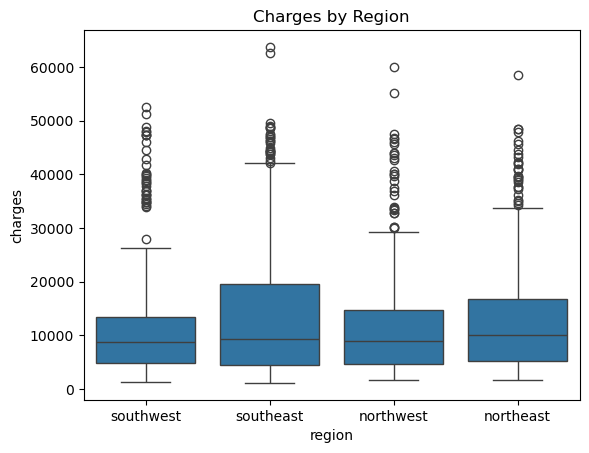

In [11]:
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()

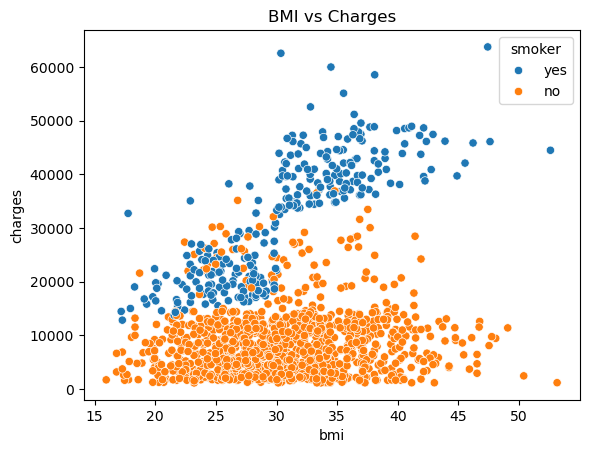

In [12]:
# Bivariate Analysis
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Charges')
plt.show()

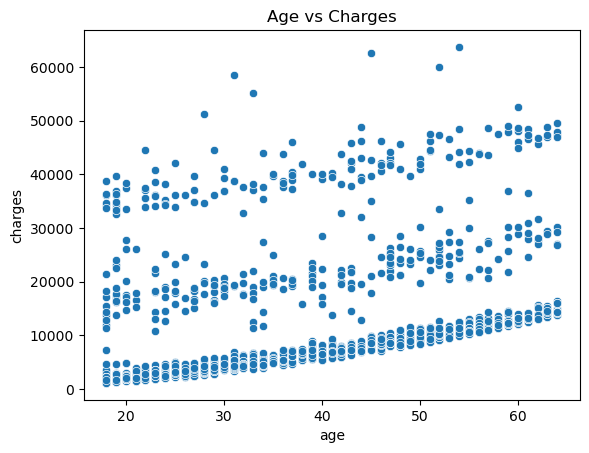

In [13]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs Charges')
plt.show()

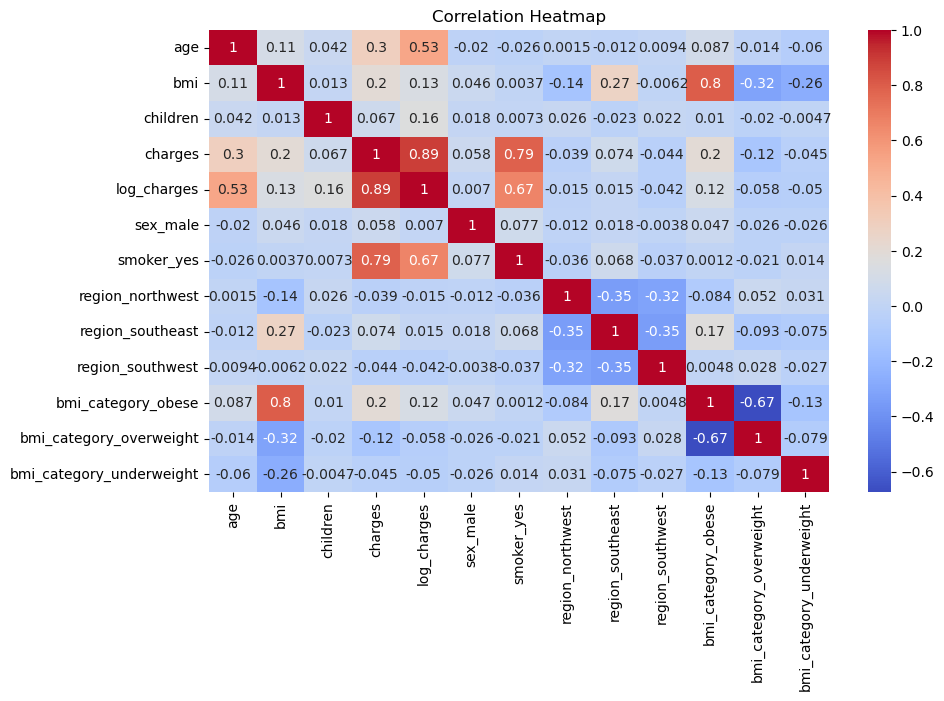

In [14]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region', 'bmi_category'], drop_first=True)

# Correlation Analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Insights
- Smokers have significantly higher charges
- BMI and age positively correlate with charges
- Charges are right-skewed (log transform helps)

## Preparing Data for Machine Learning

In [15]:
X = df_encoded.drop(['charges'], axis=1)
y = df_encoded['charges']

In [16]:
# Scaling (optional)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Saving Processed Data

In [17]:
df_encoded.to_csv('data/04-insurance_cleaned.csv', index=False)